# Mô hình Thống kê và Học sâu — Dự báo PM2.5 (t + 24h)

Notebook này thực hiện huấn luyện và cấu hình các mô hình **ARIMA, SARIMA, ARIMAX, SARIMAX** và nhóm mô hình Deep Learning **(LSTM, GRU)** để có thông số đối chiếu với nhóm thuật toán Tree-based rừ notebook 7.

- **Đầu vào:** `train_dl.csv`, `val_dl.csv`, `test_dl.csv` đã được tiền xử lý, scaling, target được log hóa.
- **Đầu ra:** Các metric **RMSE, MAE, MAPE** (hoàn tác log về thang hiển thị µg/m³ để tính sai số).
- **Trực quan hóa**: Bảng tổng kết và biểu đồ Bar Chart so sánh thực tế và dự đoán.


In [31]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import mean_squared_error, mean_absolute_error

import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42

FIG_DIR = Path("../outputs/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODELING = Path("../data/processed/modeling_fs")
TARGET_LOG = "target_pm25_h24_log"


In [32]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    
    # Do RMSE/MAE được đo bằng µg/m³, ta tiến hành hoàn tác các giá trị (inverse log)
    y_true_inv = np.expm1(y_true)
    y_pred_inv = np.expm1(y_pred)
    
    rmse = float(np.sqrt(mean_squared_error(y_true_inv, y_pred_inv)))
    mae = mean_absolute_error(y_true_inv, y_pred_inv)
    eps = 1e-6
    mask = np.abs(y_true_inv) > eps
    mape = np.mean(np.abs((y_true_inv[mask] - y_pred_inv[mask]) / y_true_inv[mask])) * 100.0
    return {"RMSE": rmse, "MAE": mae, "MAPE": mape}

def load_xy(path: Path):
    df = pd.read_csv(path, parse_dates=["datetime_local"])
    feat = [c for c in df.columns if c not in ("datetime_local", TARGET_LOG)]
    return df[feat], df[TARGET_LOG], df["datetime_local"]

train_X, train_y, train_dt = load_xy(MODELING / "train_dl.csv")
val_X, val_y, val_dt = load_xy(MODELING / "val_dl.csv")
test_X, test_y, test_dt = load_xy(MODELING / "test_dl.csv")
print(train_X.shape, val_X.shape, test_X.shape)


(6383, 26) (2128, 26) (2128, 26)


## 1. Các mô hình Thống kê: ARIMA, SARIMA, ARIMAX, SARIMAX

Chúng ta sẽ chỉ định các tham số cơ bản (có thể tinh chỉnh qua auto_arima) để lấy baseline nhanh.
- Biến nội sinh (endog): `target_pm25_h24_log`
- Biến ngoại sinh (exog): Có thể chọn một số đặc trưng mạnh như weather, pm25 lag. Do thư viện sẽ chậm lại đáng kể nếu cho hết `train_X`, ta sẽ chọn top 5 đặc trưng.


In [33]:
# Lấy ra các biến ngoại sinh
# Chọn một số cột đại diện (có thể thay đổi tuỳ kết quả Feature Selection)
exog_cols = [c for c in train_X.columns if "pm25" not in c][:5] # Ví dụ lấy 5 đặc trưng thời tiết đầu tiên

train_exog = train_X[exog_cols].values
val_exog = val_X[exog_cols].values
test_exog = test_X[exog_cols].values

train_y_vals = train_y.values
val_y_vals = val_y.values
test_y_vals = test_y.values

stats_models = {}
stats_preds_train = {}
stats_preds_val = {}
stats_preds_test = {}


In [34]:
# Hàm huần luyện và dự báo dùng Statsmodels
def fit_and_predict_stats(order, seasonal_order=None, use_exog=False, name="Model"):
    print(f"Training {name}...")
    exog_train = train_exog if use_exog else None
    
    # Training (tùy thuộc vào order mà quá trình có thể lâu)
    model = ARIMA(endog=train_y_vals, exog=exog_train, order=order, seasonal_order=seasonal_order)
    model_fit = model.fit()
    
    stats_models[name] = model_fit
    stats_preds_train[name] = model_fit.predict(start=0, end=len(train_y_vals)-1, exog=exog_train)
    
    # Dự đoán tập Validation và Test (Bằng cách update mô hình hoặc apply forecast)
    # Lấy dự báo 1 bược tiếp nhưng cho toàn bộ tập (Sử dụng append/apply để tránh retrain đầy đủ)
    model_val = model_fit.apply(endog=val_y_vals, exog=val_exog if use_exog else None)
    stats_preds_val[name] = model_val.fittedvalues
    
    model_test = model_fit.apply(endog=test_y_vals, exog=test_exog if use_exog else None)
    stats_preds_test[name] = model_test.fittedvalues
    print(f"{name} fit xong!")

# Chạy ARIMA: order=(1,1,1)
# FIT ARIMA
fit_and_predict_stats(order=(1, 1, 1), seasonal_order=(0, 0, 0, 0), use_exog=False, name="ARIMA")


Training ARIMA...
ARIMA fit xong!


In [35]:
# Chạy SARIMA: order=(1,1,1), seasonal=(1,1,1,24)
# (Tham số 24 là một ngày, có thể hạ bớt order để tránh over-complexity)
fit_and_predict_stats(order=(1, 0, 1), seasonal_order=(1, 0, 0, 24), use_exog=False, name="SARIMA")


Training SARIMA...
SARIMA fit xong!


In [36]:
# Chạy ARIMAX: order=(1,1,1), dùng Exogenous variables
fit_and_predict_stats(order=(1, 1, 1), seasonal_order=(0, 0, 0, 0), use_exog=True, name="ARIMAX")


Training ARIMAX...
ARIMAX fit xong!


In [37]:
# Chạy SARIMAX: order=(1,0,1), seasonal=(1,0,0,24), dùng Exogenous variables
fit_and_predict_stats(order=(1, 0, 1), seasonal_order=(1, 0, 0, 24), use_exog=True, name="SARIMAX")


Training SARIMAX...
SARIMAX fit xong!


## 2. Nhóm Mô hình Cạn & Học sâu: LSTM, GRU

Dữ liệu của ta có dạng feature matrix phẳng (chứa các độ trễ dưới dạng column). Ta sẽ reshape thành rank-3 `(batch, 1, num_features)` để chạy recurrent modules.

(Hoặc có thể build sequence generator đa bước, nhưng ta giữ chung form với tree-models)

In [38]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def create_dataloaders(X_tr, y_tr, X_v, y_v, X_te, y_te, batch_size=64):
    X_tr_t = torch.tensor(X_tr.values, dtype=torch.float32).unsqueeze(1) # (N, 1, features)
    y_tr_t = torch.tensor(y_tr.values, dtype=torch.float32).unsqueeze(1)
    
    X_v_t = torch.tensor(X_v.values, dtype=torch.float32).unsqueeze(1)
    y_v_t = torch.tensor(y_v.values, dtype=torch.float32).unsqueeze(1)
    
    X_te_t = torch.tensor(X_te.values, dtype=torch.float32).unsqueeze(1)
    y_te_t = torch.tensor(y_te.values, dtype=torch.float32).unsqueeze(1)
    
    train_dl = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=batch_size, shuffle=False)
    val_dl = DataLoader(TensorDataset(X_v_t, y_v_t), batch_size=batch_size, shuffle=False)
    test_dl = DataLoader(TensorDataset(X_te_t, y_te_t), batch_size=batch_size, shuffle=False)
    
    return train_dl, val_dl, test_dl, X_tr_t, X_v_t, X_te_t

train_loader, val_loader, test_loader, X_tr_t, X_v_t, X_te_t = create_dataloaders(train_X, train_y, val_X, val_y, test_X, test_y)
num_features = train_X.shape[1]


Device: cpu


In [39]:
class SimpleRNNModel(nn.Module):
    def __init__(self, rnn_type="LSTM", input_size=10, hidden_size=64, num_layers=1):
        super(SimpleRNNModel, self).__init__()
        self.rnn_type = rnn_type
        if rnn_type == "LSTM":
            self.rnn = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        else:
            self.rnn = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        if self.rnn_type == "LSTM":
            out, _ = self.rnn(x)
        else:
            out, _ = self.rnn(x)
        out = out[:, -1, :] # Chỉ lấy step cuối
        out = self.fc(out)
        return out

def train_dl_model(model, train_loader, val_loader, epochs=50, lr=1e-3):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    model.to(device)
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            preds = model(X_b)
            loss = criterion(preds, y_b)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * X_b.size(0)
            
        train_loss /= len(train_loader.dataset)
        
        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_b, y_b in val_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                preds = model(X_b)
                loss = criterion(preds, y_b)
                val_loss += loss.item() * X_b.size(0)
        val_loss /= len(val_loader.dataset)
        
        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    return model

def predict_dl(model, X_tensor):
    model.eval()
    with torch.no_grad():
        preds = model(X_tensor.to(device)).cpu().numpy().flatten()
    return preds


In [40]:
# Huấn luyện LSTM
print("\n--- Training LSTM ---")
lstm_model = SimpleRNNModel(rnn_type="LSTM", input_size=num_features, hidden_size=64, num_layers=1)
train_dl_model(lstm_model, train_loader, val_loader, epochs=50, lr=0.001)

lstm_preds_train = predict_dl(lstm_model, X_tr_t)
lstm_preds_val = predict_dl(lstm_model, X_v_t)
lstm_preds_test = predict_dl(lstm_model, X_te_t)



--- Training LSTM ---
Epoch 10 | Train Loss: 0.1532 | Val Loss: 0.2214
Epoch 20 | Train Loss: 0.1325 | Val Loss: 0.2119
Epoch 30 | Train Loss: 0.1218 | Val Loss: 0.2046
Epoch 40 | Train Loss: 0.1134 | Val Loss: 0.1990
Epoch 50 | Train Loss: 0.1064 | Val Loss: 0.1990


In [41]:
# Huấn luyện GRU
print("\n--- Training GRU ---")
gru_model = SimpleRNNModel(rnn_type="GRU", input_size=num_features, hidden_size=64, num_layers=1)
train_dl_model(gru_model, train_loader, val_loader, epochs=50, lr=0.001)

gru_preds_train = predict_dl(gru_model, X_tr_t)
gru_preds_val = predict_dl(gru_model, X_v_t)
gru_preds_test = predict_dl(gru_model, X_te_t)



--- Training GRU ---
Epoch 10 | Train Loss: 0.1515 | Val Loss: 0.2133
Epoch 20 | Train Loss: 0.1369 | Val Loss: 0.2069
Epoch 30 | Train Loss: 0.1278 | Val Loss: 0.2032
Epoch 40 | Train Loss: 0.1193 | Val Loss: 0.1988
Epoch 50 | Train Loss: 0.1116 | Val Loss: 0.1968


## 3. Tổng hợp Kết quả và Đánh giá

In [42]:
metrics_list = []

# Đưa kết quả Stats models vào bảng
for name in stats_models.keys():
    metrics_list.append({"model": name, "split": "train", **regression_metrics(train_y_vals, stats_preds_train[name])})
    metrics_list.append({"model": name, "split": "val", **regression_metrics(val_y_vals, stats_preds_val[name])})
    metrics_list.append({"model": name, "split": "test", **regression_metrics(test_y_vals, stats_preds_test[name])})

# DL Models
for name, preds_tr, preds_v, preds_te in [
    ("LSTM", lstm_preds_train, lstm_preds_val, lstm_preds_test),
    ("GRU", gru_preds_train, gru_preds_val, gru_preds_test),
]:
    metrics_list.append({"model": name, "split": "train", **regression_metrics(train_y_vals, preds_tr)})
    metrics_list.append({"model": name, "split": "val", **regression_metrics(val_y_vals, preds_v)})
    metrics_list.append({"model": name, "split": "test", **regression_metrics(test_y_vals, preds_te)})

metrics_df = pd.DataFrame(metrics_list)
display(metrics_df)


,model,split,RMSE,MAE,MAPE
0,ARIMA,train,6.857265,4.103754,13.685386
1,ARIMA,val,8.738372,6.047961,22.338320
2,ARIMA,test,10.010940,6.007037,14.402968
3,SARIMA,train,6.791861,4.460811,14.070653
4,SARIMA,val,8.298691,5.845441,21.745267
5,SARIMA,test,9.431734,5.733417,13.591756
6,ARIMAX,train,6.815867,4.097037,13.622503
7,ARIMAX,val,8.640854,6.004259,22.099290
8,ARIMAX,test,10.055330,6.068039,14.539799
9,SARIMAX,train,6.679447,4.329313,13.753764


In [43]:
# Bảng metrics trên tập Test
test_metrics = metrics_df[metrics_df["split"] == "test"].set_index("model")[["RMSE", "MAE", "MAPE"]]
display(test_metrics.round(4))


,RMSE,MAE,MAPE
model,,,
ARIMA,10.0109,6.0070,14.4030
SARIMA,9.4317,5.7334,13.5918
ARIMAX,10.0553,6.0680,14.5398
SARIMAX,9.3981,5.7698,13.9909
LSTM,18.3664,12.8074,32.5229
GRU,19.0452,13.2429,33.8028


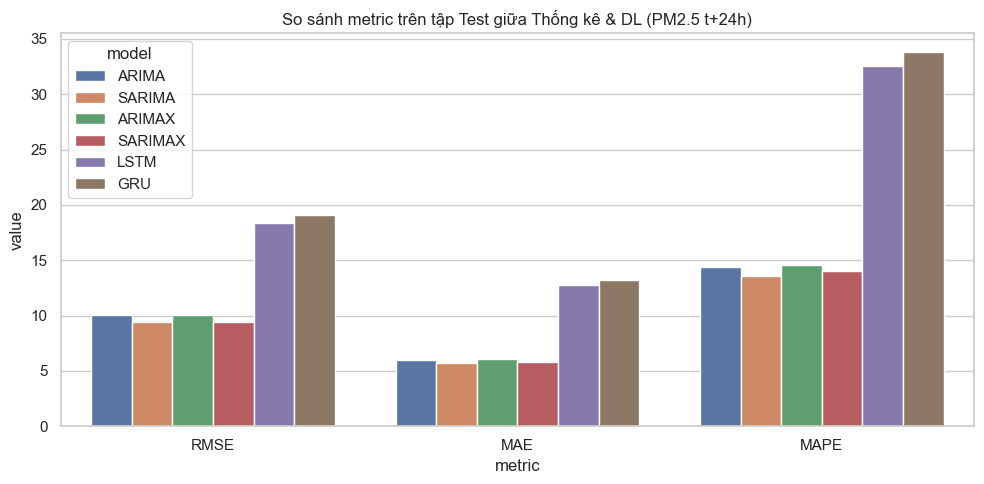

Đã lưu: C:\Users\User\Desktop\Matt Folder\Materials\MyUni\6th Semester\Business Data Analysis\Project\outputs\figures\stats_dl_models_test_metrics_bar.png


In [44]:
# Biểu đồ cột so sánh
plot_df = metrics_df[metrics_df["split"] == "test"].melt(
    id_vars=["model"], value_vars=["RMSE", "MAE", "MAPE"], var_name="metric", value_name="value"
)
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=plot_df, x="metric", y="value", hue="model", ax=ax)
ax.set_title("So sánh metric trên tập Test giữa Thống kê & DL (PM2.5 t+24h)")
plt.tight_layout()
out_bar = FIG_DIR / "stats_dl_models_test_metrics_bar.png"
fig.savefig(out_bar, dpi=150)
plt.show()
print("Đã lưu:", out_bar.resolve())


# Trực quan hóa Actual vs Predicted theo thời gian (Subset Test)
Biểu diễn một đoạn dữ liệu trên tập test để trực quan hóa khả năng dự báo của các mô hình so với thực tế.

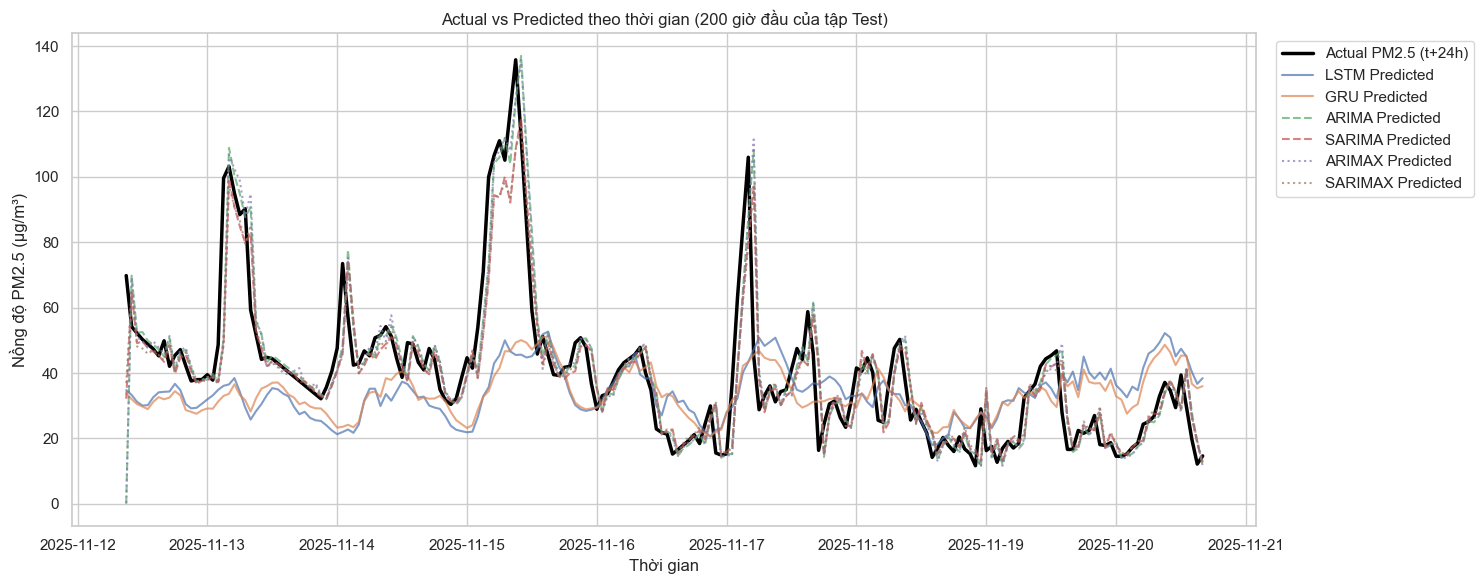

Đã lưu: C:\Users\User\Desktop\Matt Folder\Materials\MyUni\6th Semester\Business Data Analysis\Project\outputs\figures\stats_dl_models_test_timeseries.png


In [49]:
# Chọn số lượng điểm dữ liệu để trực quan (ví dụ: 200 giờ đầu tiên của tập test)
# Để biểu đồ không bị quá rối, có thể bật/tắt comment (dấu #) các dòng tương ứng với các model. 

subset_size = 200
actual_inv = np.expm1(test_y_vals[:subset_size])
lstm_pred_inv = np.expm1(lstm_preds_test[:subset_size])
gru_pred_inv = np.expm1(gru_preds_test[:subset_size])

arima_pred_inv = np.expm1(stats_preds_test['ARIMA'][:subset_size])
sarima_pred_inv = np.expm1(stats_preds_test['SARIMA'][:subset_size])
arimax_pred_inv = np.expm1(stats_preds_test['ARIMAX'][:subset_size])
sarimax_pred_inv = np.expm1(stats_preds_test['SARIMAX'][:subset_size])

fig, ax = plt.subplots(figsize=(15, 6))

# Plot Actual - Đường màu đen, đậm hơn để làm gốc so sánh
ax.plot(test_dt[:subset_size], actual_inv, label='Actual PM2.5 (t+24h)', color='black', linewidth=2.5)

# Plot DL Models
ax.plot(test_dt[:subset_size], lstm_pred_inv, label='LSTM Predicted', linestyle='-', alpha=0.7)
ax.plot(test_dt[:subset_size], gru_pred_inv, label='GRU Predicted', linestyle='-', alpha=0.7)

# Plot Stats Models
ax.plot(test_dt[:subset_size], arima_pred_inv, label='ARIMA Predicted', linestyle='--', alpha=0.7)
ax.plot(test_dt[:subset_size], sarima_pred_inv, label='SARIMA Predicted', linestyle='--', alpha=0.7)
ax.plot(test_dt[:subset_size], arimax_pred_inv, label='ARIMAX Predicted', linestyle=':', alpha=0.7)
ax.plot(test_dt[:subset_size], sarimax_pred_inv, label='SARIMAX Predicted', linestyle=':', alpha=0.7)

ax.set_title("Actual vs Predicted theo thời gian (200 giờ đầu của tập Test)")
ax.set_xlabel("Thời gian")
ax.set_ylabel("Nồng độ PM2.5 (µg/m³)")

# Kéo khung legend ra cạnh mép phải để không che khuất dữ liệu khi có nhiều mảng màu
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()

out_ts = FIG_DIR / "stats_dl_models_test_timeseries.png"
fig.savefig(out_ts, dpi=150)
plt.show()
print("Đã lưu:", out_ts.resolve())
